In [66]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from ta.momentum import RSIIndicator, ROCIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands, AverageTrueRange
from pandas.plotting import autocorrelation_plot

# Dataset Load

In [6]:
df = pd.read_csv('merged_data.csv')

# See  dataset first 5 rows

In [7]:
# See the first 5 rows
df.head().T

,0,1,2,3,4
Date,2000-01-01,2000-01-01,2000-01-01,2000-01-01,2000-01-01
Scrip,ACI,ALLTEX,AMBEEPHA,AMCL(PRAN),APEXFOODS
Open,12.674539,4.7,31.2,26.0,30.05
High,13.774594,4.75,32.0,27.0,30.5
Low,12.674539,4.7,31.2,26.0,29.95
Close,13.631108,4.7,31.6,26.525,30.175
Volume,19850,17500,1150,2500,850


# See  dataset last 5 rows

In [8]:
# See the Last 5 rows
df.tail().T

,1381566,1381567,1381568,1381569,1381570
Date,2025-02-26,2025-02-26,2025-02-26,2025-02-26,2025-02-26
Scrip,WONDERTOYS,YPL,ZAHEENSPIN,ZAHINTEX,ZEALBANGLA
Open,33.5,14.0,8.2,5.3,85.9
High,33.5,14.0,8.6,5.3,85.9
Low,27.7,13.7,8.1,5.1,83.3
Close,27.7,13.9,8.3,5.2,84.4
Volume,12663,112630,1614597,141507,1112


# Dataset Dimensions

In [9]:
# Datast shape
df.shape

(1381571, 7)

# Dataset Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1381571 entries, 0 to 1381570
Data columns (total 7 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   Date    1381571 non-null  object 
 1   Scrip   1381571 non-null  object 
 2   Open    1381571 non-null  float64
 3   High    1381571 non-null  float64
 4   Low     1381571 non-null  float64
 5   Close   1381571 non-null  float64
 6   Volume  1381571 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 73.8+ MB


# Statistical Summary

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,1381571.0,1.054704e+02,9.664946e+02,-0.274725,12.480926,26.296000,61.157025,1.037500e+06
High,1381571.0,1.068120e+02,9.678045e+02,0.000000,12.700000,26.740646,62.278239,1.037500e+06
Low,1381571.0,1.040851e+02,9.653695e+02,-0.366300,12.244900,25.750000,60.000000,1.037500e+06
Close,1381571.0,1.052271e+02,9.663991e+02,0.004381,12.426304,26.162435,60.952713,1.037500e+06
Volume,1381571.0,4.829822e+07,6.909170e+08,0.000000,20637.000000,123500.000000,497629.500000,5.607908e+10


# Dataset Columns

In [12]:
df.columns

Index(['Date', 'Scrip', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

# **EDA**

In [13]:
# Checking the missing values in this dataset
df.isna().sum()

Date      0
Scrip     0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [14]:
# Checking Duplicate values
df.duplicated().sum()

np.int64(0)

# **Visualization**

# Stock distribution

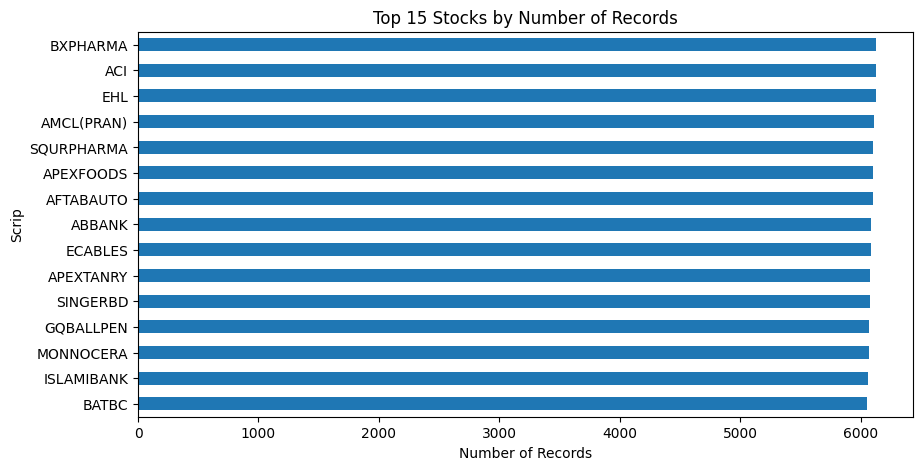

In [15]:
top_stocks = df["Scrip"].value_counts().head(15)

plt.figure(figsize=(10, 5))
top_stocks.sort_values().plot(kind="barh")

plt.title("Top 15 Stocks by Number of Records")
plt.xlabel("Number of Records")
plt.show()

# Single Stock price prediction

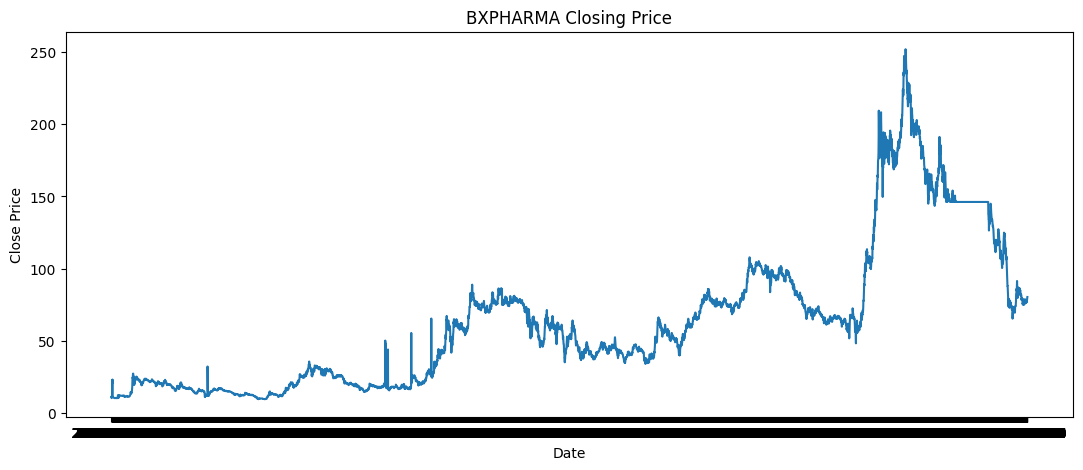

In [16]:
stock = "BXPHARMA"

data = df[df["Scrip"] == stock].copy()
data = data.sort_values("Date")

plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Close"])

plt.title(f"{stock} Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

# Volume

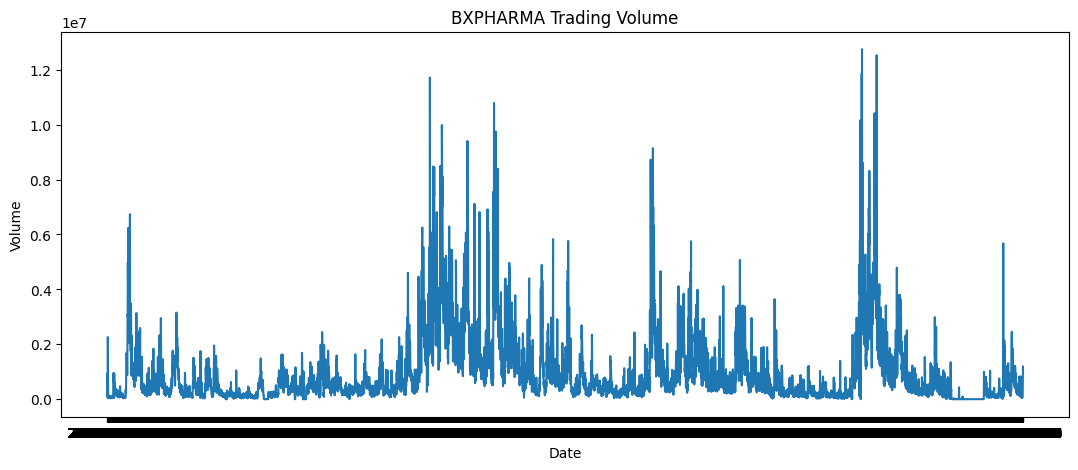

In [17]:
plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Volume"])

plt.title(f"{stock} Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

# Daily return

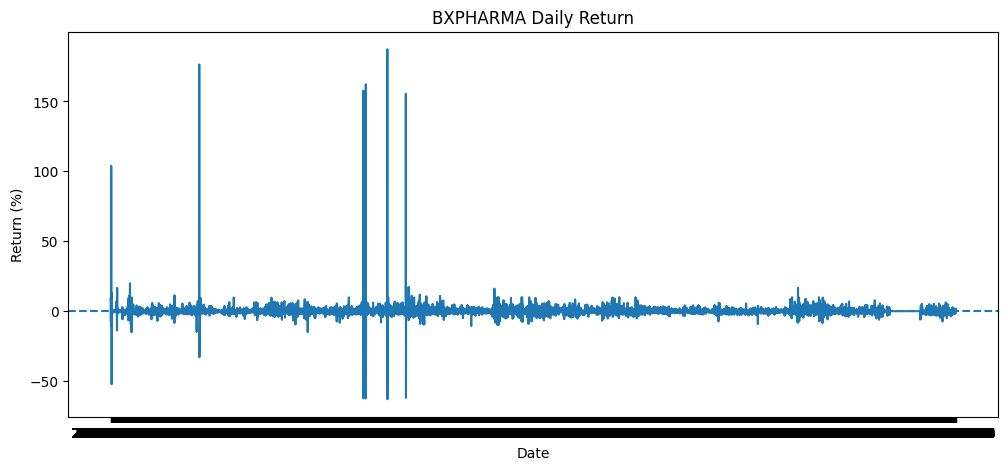

In [18]:
data["Return"] = data["Close"].pct_change() * 100

plt.figure(figsize=(12, 5))
plt.plot(data["Date"], data["Return"])

plt.axhline(0, linestyle="--")

plt.title(f"{stock} Daily Return")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.show()

# Return distribution

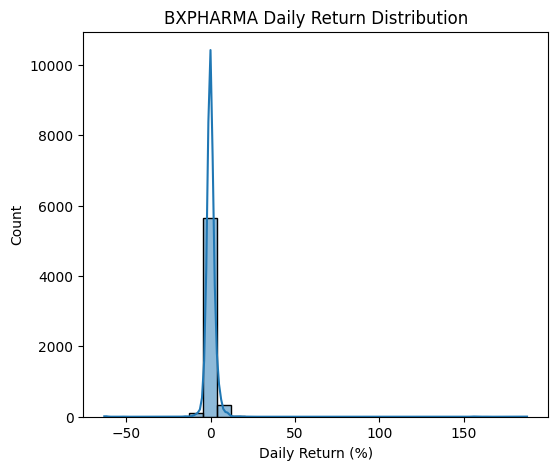

In [19]:
plt.figure(figsize=(6, 5))

sns.histplot(data["Return"].dropna(),bins=30,kde=True)

plt.title(f"{stock} Daily Return Distribution")
plt.xlabel("Daily Return (%)")
plt.show()

# Rolling volatility

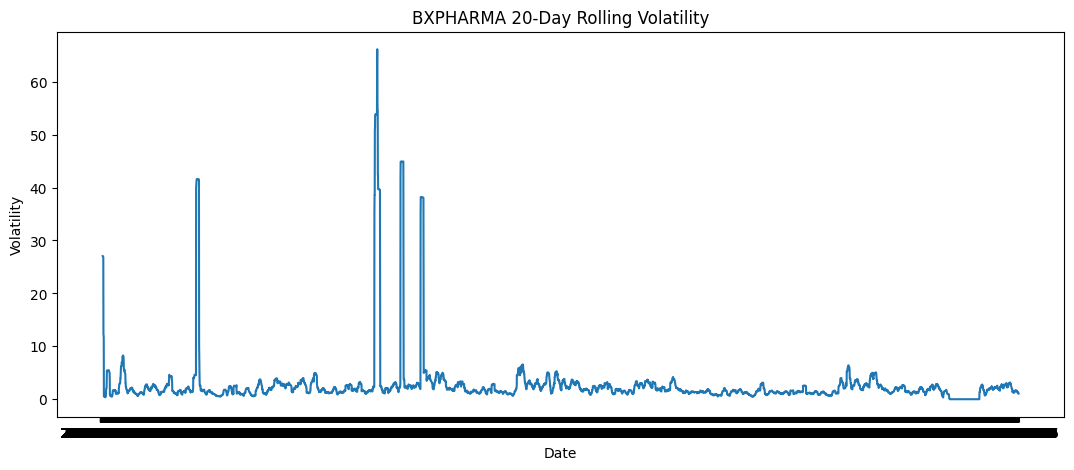

In [20]:
data["Volatility"] = data["Return"].rolling(20).std()

plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Volatility"])

plt.title(f"{stock} 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

# Volume vs return

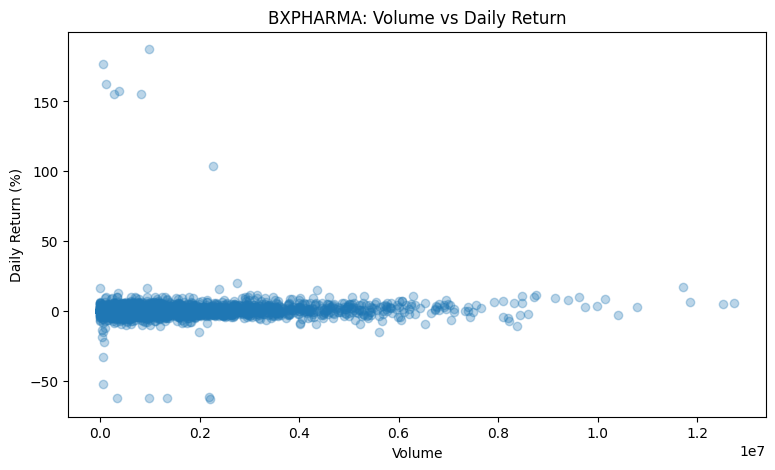

In [21]:
plt.figure(figsize=(9, 5))

plt.scatter(data["Volume"],data["Return"],alpha=0.3)

plt.xlabel("Volume")
plt.ylabel("Daily Return (%)")
plt.title(f"{stock}: Volume vs Daily Return")

plt.show()

# High-Low range

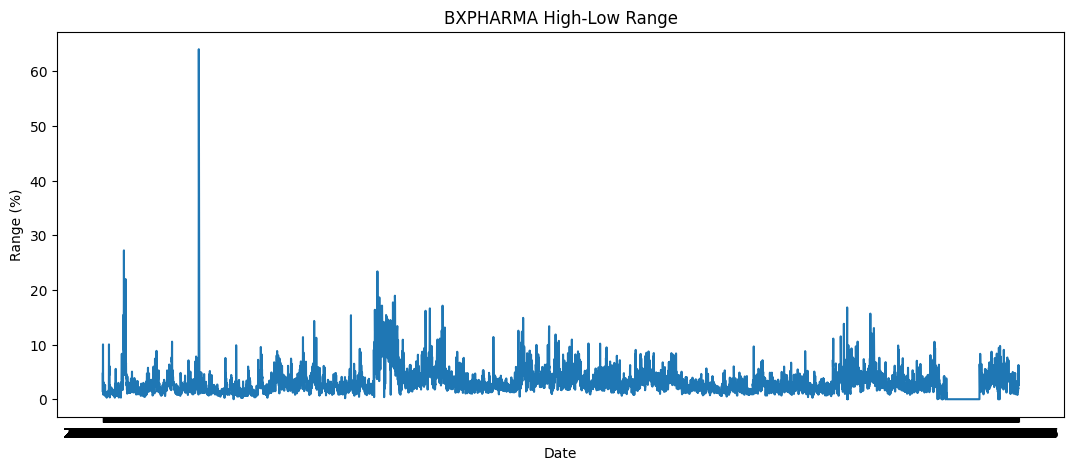

In [22]:
data["Range"] = ((data["High"] - data["Low"]) / data["Close"]) * 100

plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Range"])

plt.title(f"{stock} High-Low Range")
plt.xlabel("Date")
plt.ylabel("Range (%)")
plt.show()

# OHLC Price Trend

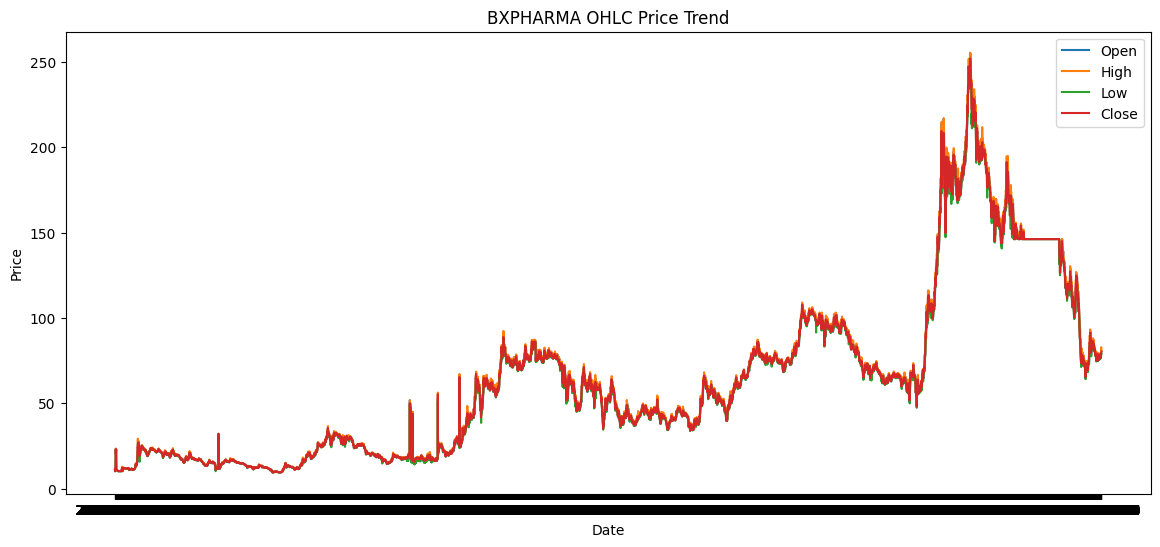

In [23]:
stock = "BXPHARMA"

data = df[df["Scrip"] == stock].copy()
data = data.sort_values("Date")

plt.figure(figsize=(14, 6))

plt.plot(data["Date"], data["Open"], label="Open")
plt.plot(data["Date"], data["High"], label="High")
plt.plot(data["Date"], data["Low"], label="Low")
plt.plot(data["Date"], data["Close"], label="Close")

plt.title(f"{stock} OHLC Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

# Different Stocks  Volatility Comparison

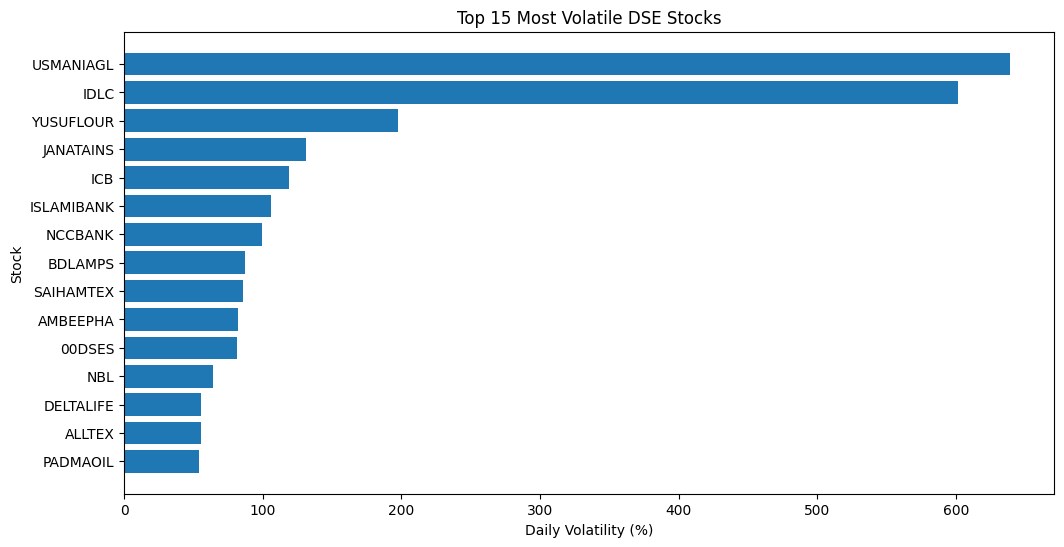

In [24]:
df["Return"] = df.groupby("Scrip")["Close"].pct_change()
volatility = (df.groupby("Scrip")["Return"].std().sort_values(ascending=False))

top_volatility = volatility.head(15).sort_values()

plt.figure(figsize=(12, 6))

plt.barh(top_volatility.index,top_volatility.values * 100)

plt.title("Top 15 Most Volatile DSE Stocks")
plt.xlabel("Daily Volatility (%)")
plt.ylabel("Stock")

plt.show()

# Return Autocorrelation

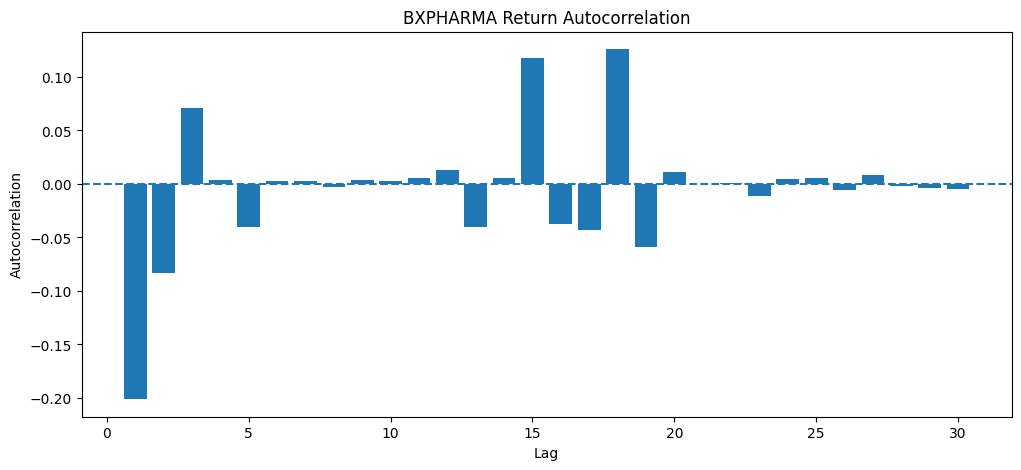

In [25]:
data["Return"] = data["Close"].pct_change()

autocorrelation = []

for lag in range(1, 31):
    value = data["Return"].autocorr(lag=lag)
    autocorrelation.append(value)

plt.figure(figsize=(12, 5))

plt.bar(range(1, 31), autocorrelation)

plt.axhline(0, linestyle="--")

plt.title(f"{stock} Return Autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.show()

# CoRelational Heatmap 

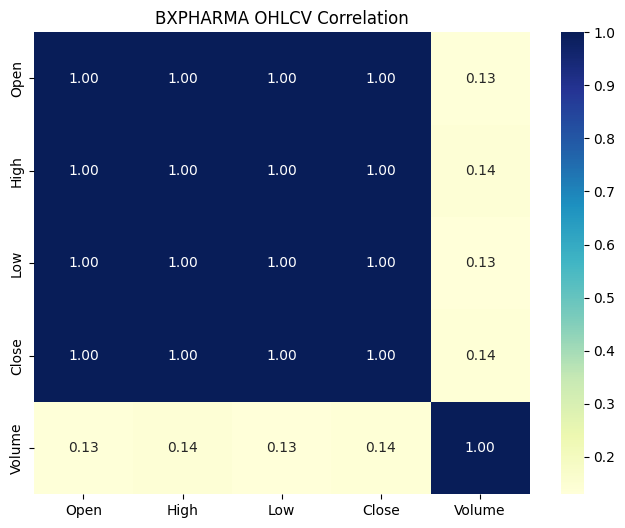

In [26]:
cols = ["Open", "High", "Low", "Close", "Volume"]

plt.figure(figsize=(8, 6))

sns.heatmap(data[cols].corr(),annot=True,cmap="YlGnBu",fmt=".2f")

plt.title(f"{stock} OHLCV Correlation")
plt.show()

# **Feature Engineering**

In [27]:
df = df.sort_values(["Scrip", "Date"]).copy()

Daily Return

In [28]:
df["Return"] = df.groupby("Scrip")["Close"].pct_change()

Lag Features

In [29]:
df["Close_Lag1"] = df.groupby("Scrip")["Close"].shift(1)
df["Close_Lag2"] = df.groupby("Scrip")["Close"].shift(2)
df["Close_Lag3"] = df.groupby("Scrip")["Close"].shift(3)
df["Close_Lag5"] = df.groupby("Scrip")["Close"].shift(5)

df["Return_Lag1"] = df.groupby("Scrip")["Return"].shift(1)
df["Return_Lag2"] = df.groupby("Scrip")["Return"].shift(2)
df["Return_Lag5"] = df.groupby("Scrip")["Return"].shift(5)

Moving Average

In [30]:
df["SMA_5"] = df.groupby("Scrip")["Close"].rolling(5).mean().reset_index(level=0, drop=True)

df["SMA_20"] = df.groupby("Scrip")["Close"].rolling(20).mean().reset_index(level=0, drop=True)

df["SMA_50"] = df.groupby("Scrip")["Close"].rolling(50).mean().reset_index(level=0, drop=True)

Exponential Moving Average

In [31]:
df["EMA_12"] = df.groupby("Scrip")["Close"].transform(lambda x: x.ewm(span=12).mean())

df["EMA_26"] = df.groupby("Scrip")["Close"].transform(lambda x: x.ewm(span=26).mean())

Rolling Volatility

In [32]:
df["Volatility_5"] = (df.groupby("Scrip")["Return"].transform(lambda x: x.rolling(5).std()))

df["Volatility_20"] = (df.groupby("Scrip")["Return"].transform(lambda x: x.rolling(20).std()))

Price Range

In [33]:
df["Price_Range"] = ((df["High"] - df["Low"]) / df["Close"])

Volume Features

In [34]:
df["Volume_Change"] = (df.groupby("Scrip")["Volume"].pct_change())
df["Volume_SMA_20"] = (df.groupby("Scrip")["Volume"].transform(lambda x: x.rolling(20).mean()))

# Dataset Shape


In [35]:
df.shape

(1381571, 25)

## Handle The Missing values after performing Feature Engineering

In [36]:
# Check the nan/ missing values
df.isna().sum()

Date                 0
Scrip                0
Open                 0
High                 0
Low                  0
Close                0
Volume               0
Return             464
Close_Lag1         464
Close_Lag2         920
Close_Lag3        1370
Close_Lag5        2265
Return_Lag1        920
Return_Lag2       1370
Return_Lag5       2709
SMA_5             1819
SMA_20            8301
SMA_50           21052
EMA_12               0
EMA_26               0
Volatility_5      2265
Volatility_20     8727
Price_Range          0
Volume_Change      569
Volume_SMA_20     8301
dtype: int64

In [37]:
# For Return handling the misssing values
df['Return'] = df['Return'].fillna(df['Return'].mean())

Handling nan values for close_Lag1 columns

In [38]:
# For close_Lag1 handling the misssing values
df['Close_Lag1'].dtype

df['Close_Lag1'] = df['Close_Lag1'].fillna(df['Close_Lag1'].std())
print("Successfully hanlde the missing value for Close_Lag1 column!")

# For close_Lag2 handling the misssing values
df['Close_Lag2'] = df['Close_Lag2'].fillna(df['Close_Lag2'].std())
print("Successfully hanlde the missing value for Close_Lag2 column!")


# For close_Lag3 handling the misssing values
df['Close_Lag3'] = df['Close_Lag3'].fillna(df['Close_Lag3'].std())
print("Successfully hanlde the missing value for Close_Lag3 column!")


# For close_Lag5 handling the misssing values
df['Close_Lag5'] = df['Close_Lag5'].fillna(df['Close_Lag5'].std())
print("Successfully hanlde the missing value for Close_Lag5 column!")

Successfully hanlde the missing value for Close_Lag1 column!
Successfully hanlde the missing value for Close_Lag2 column!
Successfully hanlde the missing value for Close_Lag3 column!
Successfully hanlde the missing value for Close_Lag5 column!


 Handling Nan values for Return_Lag columns

In [41]:
# For Return_Lag1 handling the misssing values

df['Return_Lag1'] = df['Return_Lag1'].fillna(df['Return_Lag1'].std())
print("Successfully hanlde the missing value for Return_Lag1 column!")

# For Return_Lag2 handling the misssing values
df['Return_Lag2'] = df['Return_Lag2'].fillna(df['Return_Lag2'].std())
print("Successfully hanlde the missing value for Return_Lag2 column!")


# For Return_Lag5 handling the misssing values
df['Return_Lag5'] = df['Return_Lag5'].fillna(df['Return_Lag5'].std())
print("Successfully hanlde the missing value for Return_Lag5 column!")


Successfully hanlde the missing value for Return_Lag1 column!
Successfully hanlde the missing value for Return_Lag2 column!
Successfully hanlde the missing value for Return_Lag5 column!


In [46]:
# For SMA_5 handling the misssing values

df['SMA_5'] = df['SMA_5'].fillna(df['SMA_5'].mean())
print("Successfully hanlde the missing value for Return_Lag1 column!")

# For Return_Lag2 handling the misssing values
df['SMA_20'] = df['SMA_20'].fillna(df['SMA_20'].mean())
print("Successfully hanlde the missing value for SMA_5 column!")


# For Return_Lag5 handling the misssing values
df['SMA_50'] = df['SMA_50'].fillna(df['SMA_50'].std())
print("Successfully hanlde the missing value for SMA_50 column!")

Successfully hanlde the missing value for Return_Lag1 column!
Successfully hanlde the missing value for SMA_5 column!
Successfully hanlde the missing value for SMA_50 column!


In [50]:
# For Volatility_5 handling the misssing values

df['Volatility_5'] = df['Volatility_5'].fillna(df['Volatility_5'].mean())
print("Successfully hanlde the missing value for Volatility_5 column!")

# For Volatility_20 handling the misssing values
df['Volatility_20'] = df['Volatility_20'].fillna(df['Volatility_20'].mean())
print("Successfully hanlde the missing value for Volatility_20 column!")

Successfully hanlde the missing value for Volatility_5 column!
Successfully hanlde the missing value for Volatility_20 column!


In [54]:
# For Volume_Change handling the misssing values

df['Volume_Change'] = df['Volume_Change'].fillna(df['Volume_Change'].median())
print("Successfully hanlde the missing value for Volume_Change column!")

# For Volume_SMA_20 handling the misssing values
df['Volume_SMA_20'] = df['Volume_SMA_20'].fillna(df['Volume_SMA_20'].mean())
print("Successfully hanlde the missing value for Volume_SMA_20 column!")

Successfully hanlde the missing value for Volume_Change column!
Successfully hanlde the missing value for Volume_SMA_20 column!


In [55]:
df.isna().sum()

Date             0
Scrip            0
Open             0
High             0
Low              0
Close            0
Volume           0
Return           0
Close_Lag1       0
Close_Lag2       0
Close_Lag3       0
Close_Lag5       0
Return_Lag1      0
Return_Lag2      0
Return_Lag5      0
SMA_5            0
SMA_20           0
SMA_50           0
EMA_12           0
EMA_26           0
Volatility_5     0
Volatility_20    0
Price_Range      0
Volume_Change    0
Volume_SMA_20    0
dtype: int64

In [57]:
df.columns

Index(['Date', 'Scrip', 'Open', 'High', 'Low', 'Close', 'Volume', 'Return',
       'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'Close_Lag5', 'Return_Lag1',
       'Return_Lag2', 'Return_Lag5', 'SMA_5', 'SMA_20', 'SMA_50', 'EMA_12',
       'EMA_26', 'Volatility_5', 'Volatility_20', 'Price_Range',
       'Volume_Change', 'Volume_SMA_20'],
      dtype='object')

BXPHARMA Close Price and EMA 

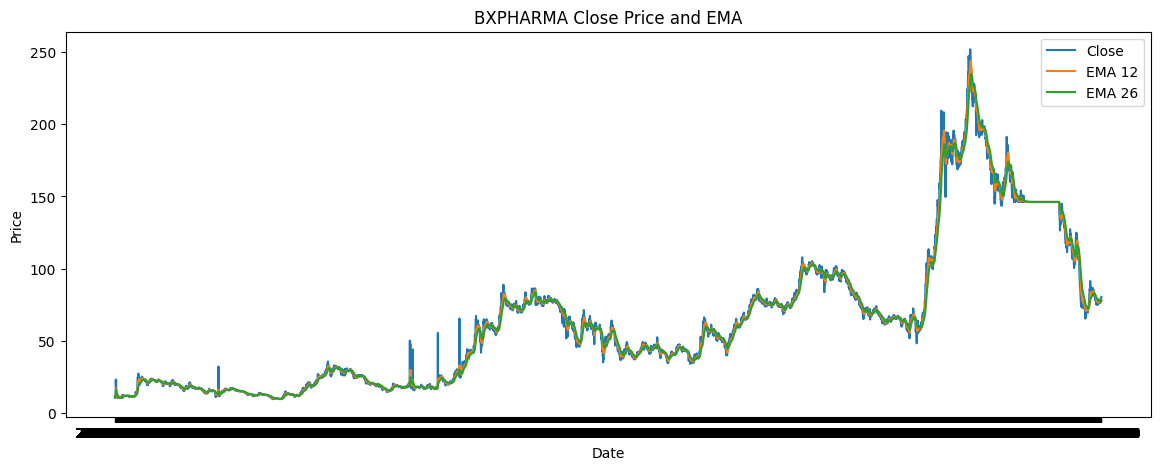

In [62]:
stock = "BXPHARMA"

plt.figure(figsize=(14, 5))

temp = df[df["Scrip"] == stock]

plt.plot(temp["Date"], temp["Close"], label="Close")
plt.plot(temp["Date"], temp["EMA_12"], label="EMA 12")
plt.plot(temp["Date"], temp["EMA_26"], label="EMA 26")

plt.title(f"{stock} Close Price and EMA")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.show()

## **RSI**

In [67]:
rsi = RSIIndicator(df["Close"], window=14)

df["RSI"] = rsi.rsi()